Titanik Veri Seti - Keşifçi Veri Analizi (EDA)

Bu projede Titanik veri seti üzerinde Keşifçi Veri Analizi (EDA), veri temizleme ve özellik mühendisliği çalışmaları gerçekleştirilmiştir.
Analizin amacı, yolcuların demografik ve seyahat özellikleri ile hayatta kalma durumu arasındaki ilişkileri incelemektir.

In [199]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [200]:
train_data=pd.read_csv("train.csv")

In [201]:
train_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [202]:
train_data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [203]:
def degiskenler(variable):
    cat=train_data[variable]
    sayi=cat.value_counts()
    plt.figure(figsize=(9,3))
    plt.bar(sayi.index,sayi)
    plt.title(variable)
    plt.show()
    print(variable,sayi)
    

In [204]:
category1=["Survived","Sex","Pclass","SibSp","Parch"]

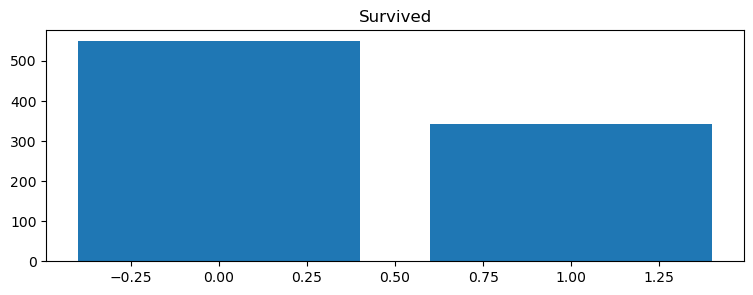

Survived Survived
0    549
1    342
Name: count, dtype: int64


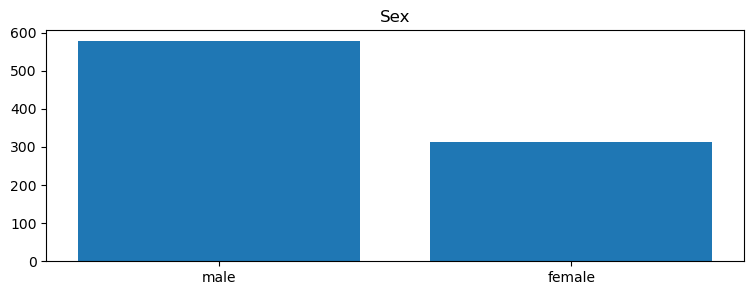

Sex Sex
male      577
female    314
Name: count, dtype: int64


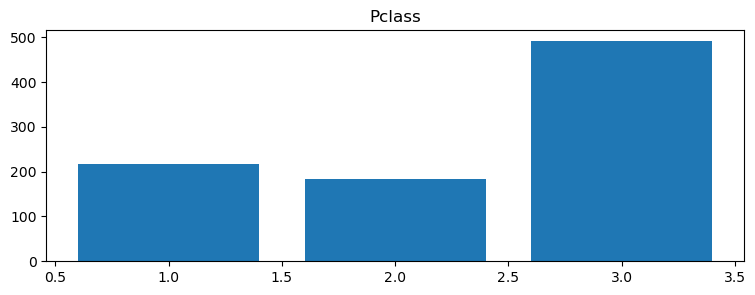

Pclass Pclass
3    491
1    216
2    184
Name: count, dtype: int64


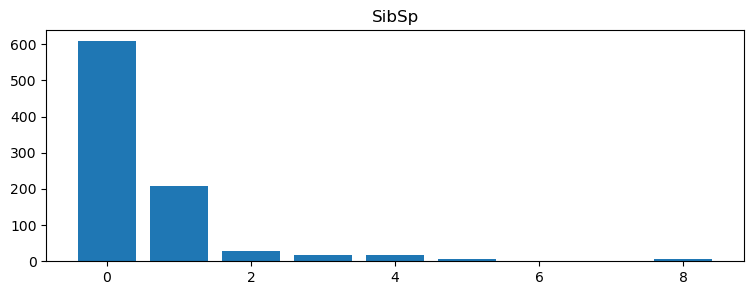

SibSp SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64


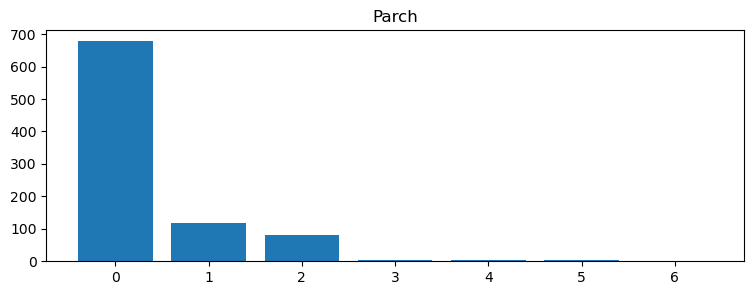

Parch Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64


In [205]:
for i in category1:
    degiskenler(i)


In [206]:
def hist(variable):
    plt.figure(figsize=(9,3))
    plt.hist(train_data[variable])
    plt.xlabel(variable)
    plt.ylabel("frekans")
    plt.title(variable)
    plt.show()

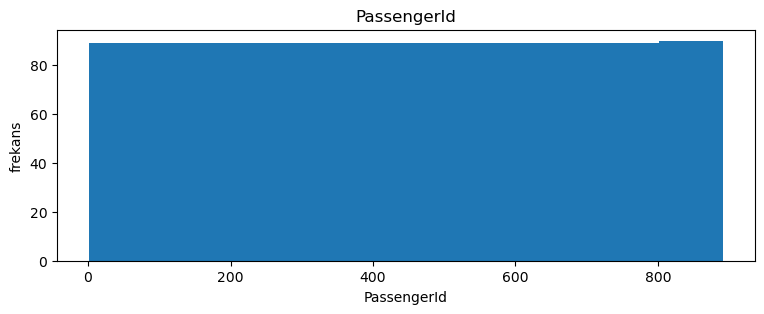

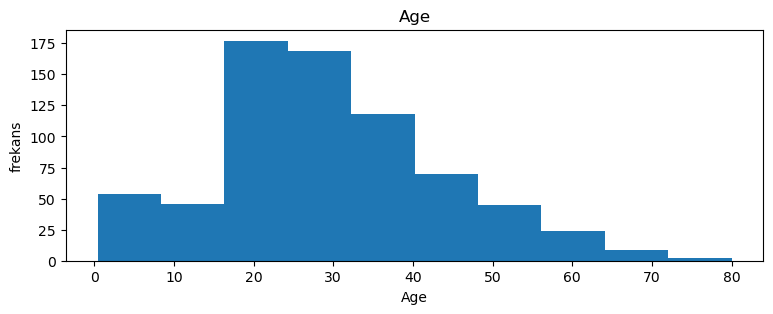

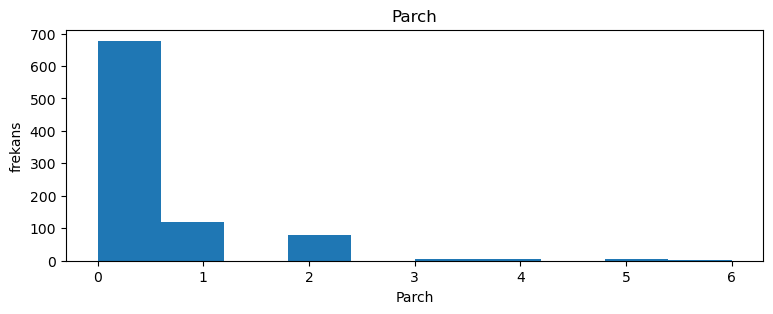

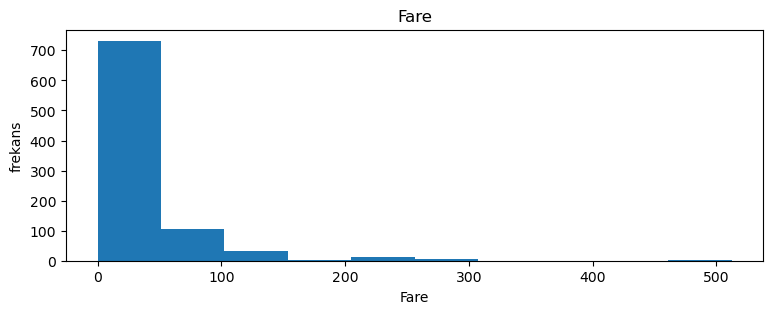

In [207]:
category2=["PassengerId","Age","Parch","Fare"]
for i in category2:
    hist(i)


Demografik Analiz: Cinsiyet ve Bilet Sınıfı Etkisi

Cinsiyet ve bilet sınıfının hayatta kalma oranları üzerindeki ilişkisini incelemek amacıyla bu iki değişken analiz edilmiştir.

In [208]:
train_data[["Pclass","Survived"]].groupby(["Pclass"],as_index=False).mean().sort_values(by="Survived",ascending=False)

,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


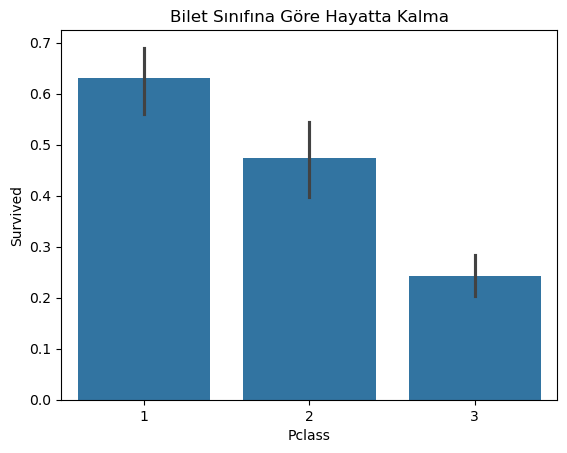

In [209]:
sns.barplot(x="Pclass", y="Survived", data=train_data)
plt.title("Bilet Sınıfına Göre Hayatta Kalma")
plt.show()

In [210]:
train_data[["Sex","Survived"]].groupby(["Sex"],as_index=False).mean().sort_values(by="Survived",ascending=False)

,Sex,Survived
0,female,0.742038
1,male,0.188908


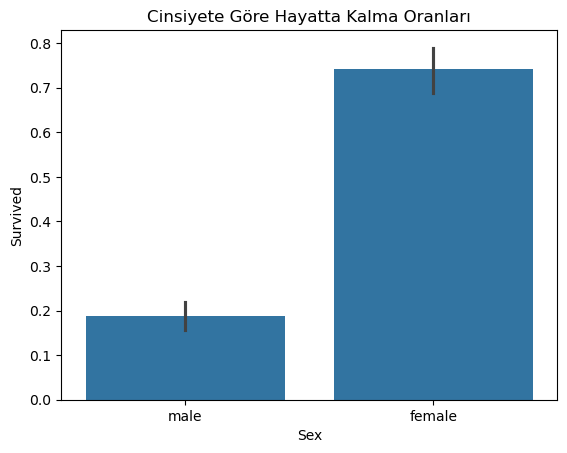

In [211]:
sns.barplot(x="Sex", y="Survived", data=train_data)
plt.title("Cinsiyete Göre Hayatta Kalma Oranları")
plt.show()

Cinsiyet:
Kadınların hayatta kalma oranı (%74), erkeklerin hayatta kalma oranına (%18) göre belirgin şekilde daha yüksektir. Bu sonuç, cinsiyet ile hayatta kalma arasında güçlü bir ilişki olduğunu göstermektedir.

Sınıf: 
1.sınıf yolcuların hayatta kalma oranı (%62), 3. sınıf yolcuların hayatta kalma oranına (%24) göre belirgin şekilde daha yüksektir. Bu sonuç, yolcuların sosyal sınıfı ile hayatta kalma arasında belirgin bir ilişki olduğunu göstermektedir

In [212]:
train_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [213]:
train_data[train_data["Embarked"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


<Axes: title={'center': 'Fare'}, xlabel='Embarked'>

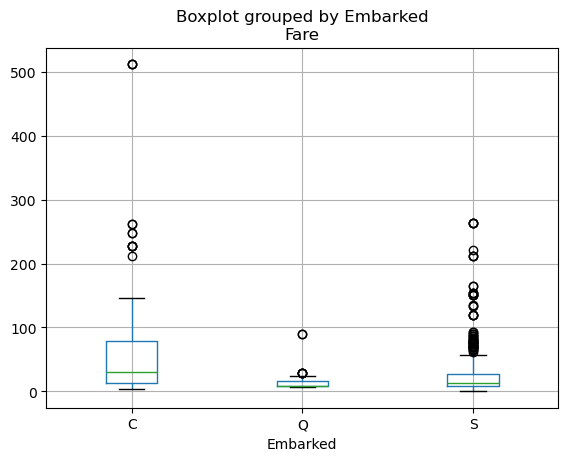

In [214]:
train_data.boxplot(column="Fare",by="Embarked")

In [215]:
train_data["Embarked"]=train_data["Embarked"].fillna("C")

In [216]:
train_data[train_data["Embarked"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


Özellik Mühendisliği (Feature Engineering) ve Eksik Veriler

Age sütununda 177 adet eksik veri bulunmaktadır. Bu eksiklikleri tüm geminin yaş ortalamasıyla doldurmak, 
verideki standart sapmayı bozacak ve analizi yanıltacaktır.

Bunun yerine Name sütunundan yolcuların unvanları çıkarılarak sosyal statüleri (Mr, Mrs, Miss, Master, Rare) belirlenmiştir. Eksik yaşlar, her yolcunun kendi unvan grubunun medyan değeri ile doldurulmuş, böylece çocuklara (Master) veya yetişkinlere (Mr/Mrs) en uygun yaş istatistiksel bir temelle atanmıştır.

In [217]:
train_data["Title"] = train_data["Name"].str.extract(r',\s*([^\.]*)\.')

In [218]:
train_data["Title"].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [219]:
train_data["Title"] = train_data["Title"].replace(
    ["Lady","the Countess","Capt","Col","Don","Dr","Major","Rev","Sir","Jonkheer","Dona"],
    "Rare"
)
train_data["Title"] = train_data["Title"].replace(["Mlle","Ms"], "Miss")
train_data["Title"] = train_data["Title"].replace("Mme", "Mrs")

In [220]:
train_data["Title"].value_counts()

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

In [221]:
train_data["Age"] = train_data.groupby("Title")["Age"].transform(
    lambda x: x.fillna(x.median())
)

In [222]:
train_data["Age"].isnull().sum()

np.int64(0)

Yolcuların kabin numaralarından , bulundukları güverte harfleri (Deck) türetilmiştir. Kabin bilgisi olmayan çok sayıda yolcu "Bilinmiyor" olarak etiketlenmiştir.

In [223]:
train_data["Deck"] = train_data["Cabin"].str[0]

In [224]:
train_data["Deck"] = train_data["Deck"].fillna("Bilinmiyor")

In [225]:
train_data["Deck"].value_counts()

Deck
Bilinmiyor    687
C              59
B              47
D              33
E              32
A              15
F              13
G               4
T               1
Name: count, dtype: int64

In [226]:
train_data[["Deck", "Survived"]].groupby("Deck", as_index=False).mean().sort_values(by="Survived", ascending=False)

,Deck,Survived
4,D,0.757576
5,E,0.750000
1,B,0.744681
6,F,0.615385
3,C,0.593220
7,G,0.500000
0,A,0.466667
2,Bilinmiyor,0.299854
8,T,0.000000


In [227]:
train_data = train_data.drop(columns=["Cabin"])

In [228]:
train_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title,Deck
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Mr,Bilinmiyor
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Mrs,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Miss,Bilinmiyor
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Mrs,C
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Mr,Bilinmiyor
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,Rare,Bilinmiyor
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,Miss,B
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,21.0,1,2,W./C. 6607,23.4500,S,Miss,Bilinmiyor
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,Mr,C
